In [19]:
import matplotlib.pyplot as plt
import PcmPy as pcm
import numpy as np
import os
import pandas as pd
from pathlib import Path
import sys
from SensoriMotorPrediction.vis import plot_rdm, plot_correlation
from SensoriMotorPrediction.force import calc_G_force
import SensoriMotorPrediction.globals as gl

In [20]:
experiment = 'smp2'
H = 'L'
glm = 15

# Representation geometry in force patterns before perturbation onset (Fig. 5a)

force: tval=3.2576122221408705, pval=0.0031180970089363883


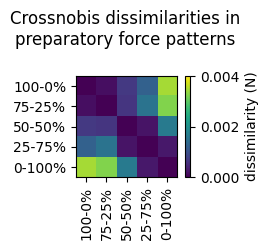

In [21]:
behav_block_cue = pd.read_csv(os.path.join(gl.baseDir, 'smp2', gl.behavDir, 'behaviour.block.cue.tsv'), sep='\t')
G_force, G_force_der = calc_G_force(behav_block_cue, prewhiten=False)
D_force = pcm.G_to_dist(G_force)
vmin, vmax = 0, .004
fig, ax = plt.subplots(figsize=(3, 2.5))
fig, ax = plot_rdm(fig, ax, None, D_force, gl.cues, sqrt=False, source='force', vmin=vmin, vmax=vmax)
cax = ax.get_images()[0]
cbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=.04)
cbar.set_label('dissimilarity (N)')
fig.suptitle('Crossnobis dissimilarities in\npreparatory force patterns')
fig.tight_layout()
fig.savefig(os.path.join('figures', 'crossnobis.force.pdf'))
plt.show()

# Mean force difference between cued and uncued finger during preparation

In [22]:
filepath = os.path.join(gl.baseDir, experiment, gl.behavDir, f'behaviour.trial.tsv')
dat = pd.read_csv(filepath, sep='\t', )
dat = dat[(dat['cue']=='0-100%') | (dat['cue']=='0-100%')]
dat = dat.groupby(['sn']).mean(numeric_only=True).reset_index()
print('--- AVERAGE FORCE DIFFERENCE BETWEEN CUED AND UNCUED---')
print(f'{dat.forceDiff.mean()}+/-{dat.forceDiff.std() / np.sqrt(len(dat.sn.unique()))}')


--- AVERAGE FORCE DIFFERENCE BETWEEN CUED AND UNCUED---
0.05000936861742333+/-0.02505079810941822


# Linear regression between BOLD and force mean dissimilarity (Fig. 5b)


M1
slope: -2.5048251207317764, p = 0.519
intercept: 0.03061234028240395, p_intercept = 0.000
R2 = 0.035

S1
slope: -2.186335017380898, p = 0.707
intercept: 0.024916221685485712, p_intercept = 0.015
R2 = 0.012


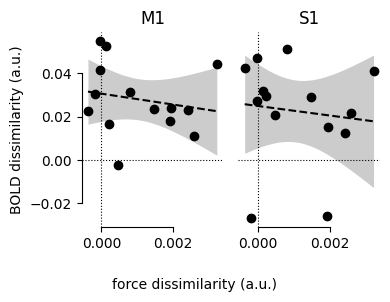

In [23]:
rois_tmp = ['M1', 'S1']

fig, axs = plt.subplots(1, len(rois_tmp), sharex=True, sharey=True, figsize=(4, 3))

x = D_force.mean(axis=(1, 2))

for r, roi in enumerate(rois_tmp):
    print(f'\n{roi}')
    G = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    D = np.array([pcm.G_to_dist(Gg) for Gg in G])
    y = D.mean(axis=(1, 2))
    fig, axs =  plot_correlation(fig, axs, r, x, y, alternative_slope='two-sided', alternative_intercept='two-sided')
    axs[r].set_title(roi)

for ax in axs:
    yticks = ax.get_yticks()
    xticks = ax.get_xticks()
    ax.spines['left'].set_bounds(yticks[1], yticks[-2])
    ax.spines['bottom'].set_bounds(xticks[1], xticks[-2])

axs[0].set_ylabel('BOLD dissimilarity (a.u.)', fontsize=10)
axs[1].tick_params('y', left=False)
fig.supxlabel('force dissimilarity (a.u.)', fontsize=10)

fig.tight_layout()

plt.show()